### 数据集

In [119]:
import numpy as np
import matplotlib.pyplot as plt

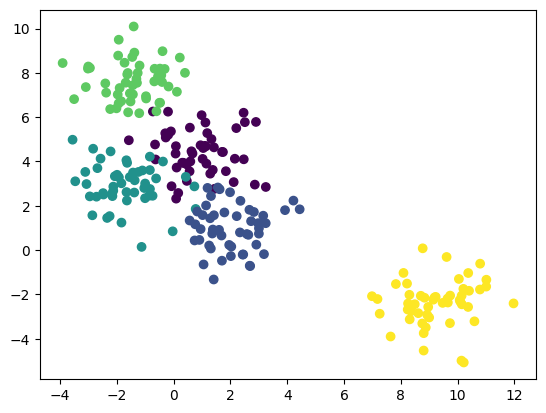

In [120]:
from sklearn.datasets import make_blobs  # 导入 make_blobs，用于生成聚类模拟数据
X, y = make_blobs(
    n_samples=250,      # 样本数量
    centers=5,          # 聚类中心数量，即生成 5 个簇
    n_features=2,       # 每个样本包含 2 个特征，方便二维可视化
    random_state=0)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

### K-Means聚类

In [121]:
from sklearn.cluster import KMeans

In [122]:
kmeans = KMeans(n_clusters=5, random_state=0)
kmeans.fit(X);

In [123]:
kmeans.labels_

array([1, 1, 2, 0, 3, 2, 0, 2, 4, 3, 1, 2, 4, 3, 0, 3, 3, 1, 3, 2, 2, 2,
       1, 0, 0, 0, 2, 4, 1, 0, 2, 2, 3, 4, 1, 3, 3, 1, 3, 3, 1, 4, 0, 2,
       2, 4, 4, 3, 2, 0, 2, 0, 0, 0, 4, 3, 4, 1, 2, 2, 2, 4, 3, 4, 4, 2,
       1, 4, 1, 2, 2, 3, 1, 3, 0, 2, 3, 0, 0, 1, 0, 1, 2, 4, 3, 2, 4, 1,
       3, 4, 2, 4, 0, 2, 1, 0, 4, 3, 2, 3, 1, 4, 3, 2, 4, 4, 2, 1, 4, 2,
       2, 4, 4, 0, 4, 0, 2, 3, 4, 1, 1, 2, 3, 1, 4, 4, 1, 3, 3, 4, 1, 1,
       2, 3, 3, 1, 2, 0, 4, 4, 3, 2, 3, 0, 3, 4, 3, 2, 1, 2, 0, 2, 1, 4,
       0, 4, 4, 0, 4, 3, 3, 0, 0, 2, 0, 1, 2, 0, 3, 4, 4, 1, 3, 3, 2, 1,
       1, 0, 1, 3, 0, 4, 0, 0, 2, 1, 4, 0, 3, 0, 0, 3, 4, 1, 1, 3, 0, 3,
       0, 4, 1, 3, 0, 0, 0, 1, 4, 3, 2, 1, 4, 4, 3, 2, 4, 1, 1, 2, 4, 1,
       4, 3, 2, 0, 4, 4, 2, 2, 3, 3, 2, 3, 3, 0, 2, 0, 0, 1, 1, 0, 3, 0,
       2, 0, 1, 4, 1, 4, 0, 0], dtype=int32)

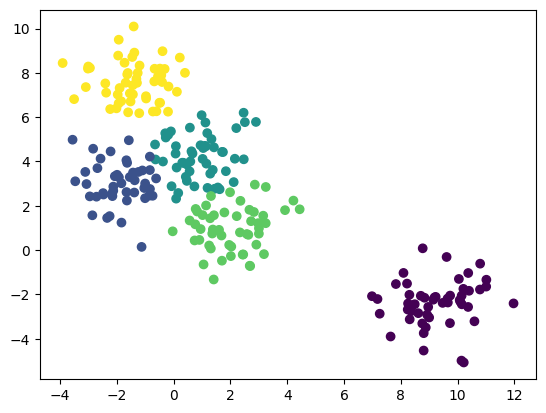

In [124]:
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_)
plt.show()

In [125]:
center = kmeans.cluster_centers_
center

array([[ 9.27996402, -2.3764533 ],
       [-1.89417429,  2.99441922],
       [ 0.91572194,  4.23535865],
       [ 2.05849588,  0.9767519 ],
       [-1.39550161,  7.57857088]])

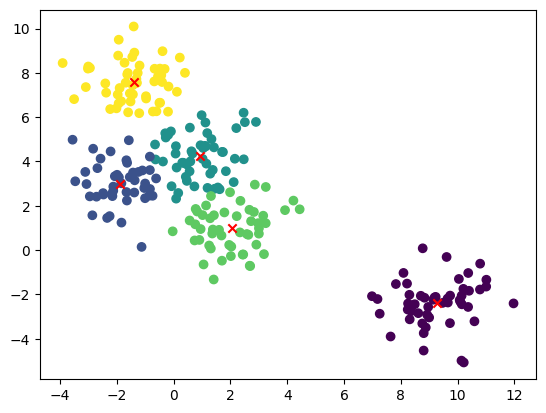

In [126]:
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_)
plt.scatter(center[:,0], center[:,1], c='red', marker='x')
plt.show()

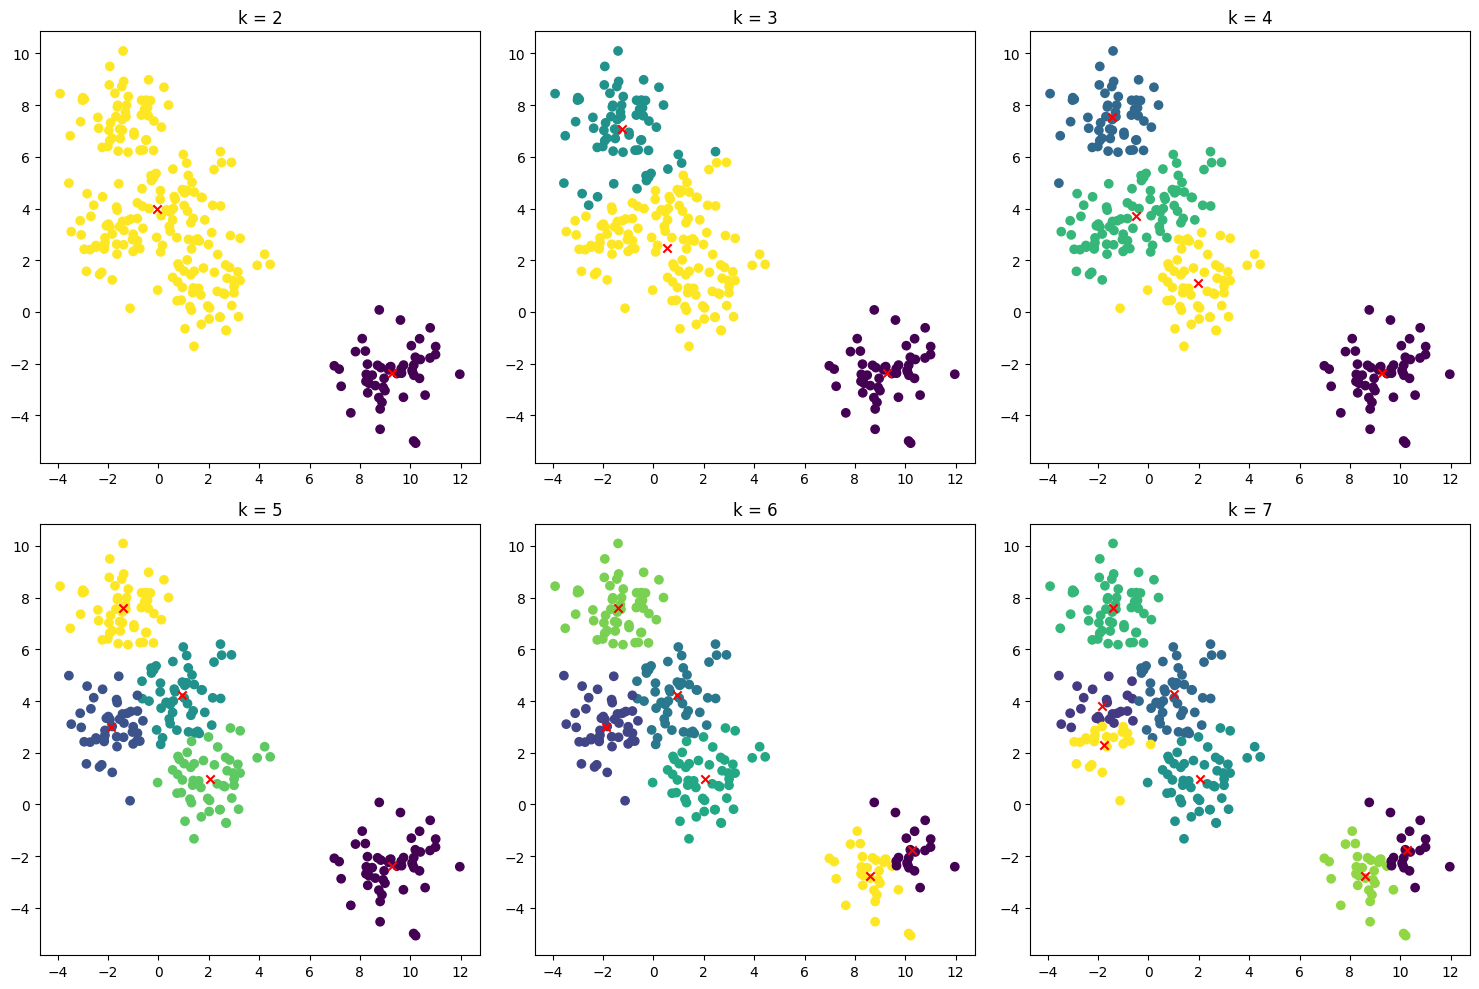

In [127]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
for i, n_clusters in enumerate([2, 3, 4, 5, 6, 7]):
    clusterer = KMeans(n_clusters=n_clusters, random_state=0).fit(X)
    z = clusterer.labels_
    center = clusterer.cluster_centers_
    axes[i].scatter(X[:, 0], X[:, 1], c=z)
    axes[i].scatter(center[:, 0], center[:, 1], marker='x', c='red')
    axes[i].set_title(f"k = {n_clusters}")
plt.tight_layout()
plt.show()

### 层次聚类

In [128]:
from sklearn.cluster import AgglomerativeClustering

In [129]:
agg = AgglomerativeClustering(
    linkage="ward",
    n_clusters=5,)
agg.fit(X);

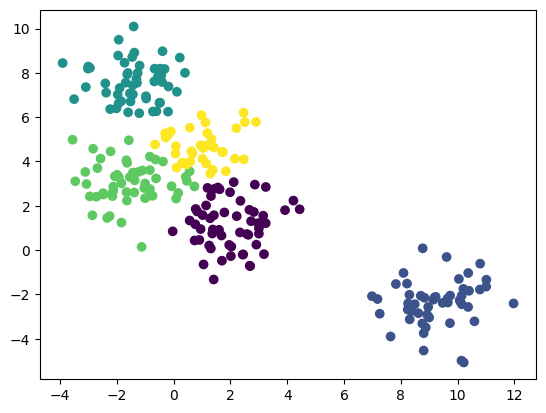

In [130]:
plt.scatter(X[:, 0], X[:, 1], c=agg.labels_)
plt.show()

In [131]:
agg = AgglomerativeClustering(
    distance_threshold=10,
    n_clusters=None)
agg.fit(X);

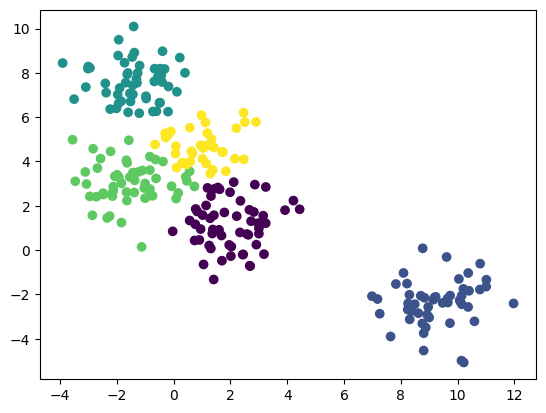

In [132]:
plt.scatter(X[:, 0], X[:, 1], c=agg.labels_)
plt.show()

In [133]:
from scipy.cluster.hierarchy import linkage, dendrogram
def show_dendrogram(model):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)
    dendrogram(linkage_matrix)

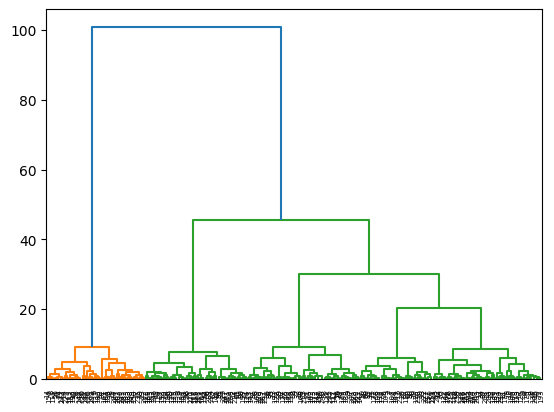

In [134]:
show_dendrogram(agg)